# Entrega 2 — Comparación de familias de modelos y validación

---

### Estructura del notebook

| Sección | Contenido |
|---|---|
| **1. Configuración** | Imports, semilla, estilos |
| **2. Carga y preprocesamiento** | Datos, separación, pipelines base |
| **3. Capa 1 — Experimento principal** | LR · RF · LightGBM con 5-fold CV |
| **4. Capa 2 — Experimento de leakage** | Con vs sin `duration` |
| **5. Capa 3 — Experimento de desbalance** | 3 modelos × 3 técnicas (9 configs) |
| **6. Análisis de umbral** | Curvas PR y umbral óptimo |
| **7. Análisis de errores** | Matriz de confusión y perfiles de error |
| **8. Decisión provisional** | Mejor familia y justificación |


---
## 1. Configuración del entorno

In [1]:
# ── Imports estándar ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Scikit-learn: preprocesamiento ────────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)

# ── Scikit-learn: modelos ─────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

# ── Scikit-learn: métricas ────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_recall_curve, classification_report,
    ConfusionMatrixDisplay
)

# ── Manejo de desbalance ──────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ── Semilla global ────────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Estilo de gráficas ────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
PALETTE = ["#2C6EAB", "#E84855", "#F4A261"]

print("Entorno configurado correctamente.")

Entorno configurado correctamente.


---
## 2. Carga de datos y preprocesamiento base

Retomamos exactamente el mismo punto de partida de la Entrega 1:
- División 80/20 estratificada con `random_state=42`
- `duration` excluida desde el inicio por *data leakage*
- El conjunto de **test no se toca** hasta la evaluación final (Sección 7)

In [2]:
# ── Carga del dataset ─────────────────────────────────────────────────────────
df = pd.read_csv("../data/bank-full.csv", sep=";")

TARGET       = "y"
LEAKAGE_COLS = ["duration"]   # excluida por leakage (conocida solo post-llamada)

X_full = df.drop(columns=[TARGET] + LEAKAGE_COLS)
y_full = (df[TARGET] == "yes").astype(int)   # yes=1, no=0

# ── División 80/20 estratificada ──────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full,
    test_size    = 0.20,
    random_state = RANDOM_STATE,
    stratify     = y_full
)

print(f"Train : {X_train.shape[0]:,} registros  |  positivos: {y_train.mean():.3f}")
print(f"Test  : {X_test.shape[0]:,}  registros  |  positivos: {y_test.mean():.3f}")
print()
print("Regla anti-leakage activa:")
print("  → 'duration' excluida desde la separación de conjuntos.")
print("  → X_test no se usa hasta la Sección 7 (evaluación final).")

Train : 36,168 registros  |  positivos: 0.117
Test  : 9,043  registros  |  positivos: 0.117

Regla anti-leakage activa:
  → 'duration' excluida desde la separación de conjuntos.
  → X_test no se usa hasta la Sección 7 (evaluación final).


In [3]:
# ── Identificación de columnas por tipo ───────────────────────────────────────
#
# Separamos las columnas en numéricas y categóricas para construir
# el ColumnTransformer, que aplica transformaciones distintas a cada grupo.

NUM_COLS = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
CAT_COLS = X_train.select_dtypes(include="object").columns.tolist()

print(f"Variables numéricas  ({len(NUM_COLS)}): {NUM_COLS}")
print(f"Variables categóricas ({len(CAT_COLS)}): {CAT_COLS}")

Variables numéricas  (6): ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Variables categóricas (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [4]:
# ── Preprocesador base (reutilizable en todos los pipelines) ──────────────────
#
# StandardScaler: centra y escala las variables numéricas (media=0, std=1).
#   → Necesario para la Regresión Logística; neutral para RF y LightGBM.
#
# OneHotEncoder: convierte variables categóricas en columnas binarias.
#   → handle_unknown='ignore': si aparece una categoría nueva en test,
#     la trata como ceros en lugar de lanzar error.
#   → sparse_output=False: devuelve array denso (más fácil de depurar).
#
# CRÍTICO: este preprocesador se ajusta SOLO sobre X_train dentro del pipeline.
# Nunca ve X_test antes de la predicción final.

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), NUM_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS)
])

print("Preprocesador base construido:")
print("  → Numérico : StandardScaler")
print("  → Categórico: OneHotEncoder (handle_unknown='ignore')")

Preprocesador base construido:
  → Numérico : StandardScaler
  → Categórico: OneHotEncoder (handle_unknown='ignore')


In [5]:
# ── Configuración de la validación cruzada ────────────────────────────────────
#
# StratifiedKFold con 5 pliegues: divide el train en 5 partes iguales,
# entrenando en 4 y evaluando en 1, rotando el pliegue de evaluación.
# El parámetro 'stratify' preserva la proporción de clases (88/12) en cada
# pliegue, lo que es fundamental con datasets desbalanceados.
#
# 5 pliegues es el estándar que balancea bien sesgo-varianza y costo
# computacional para este tamaño de dataset (~36K registros en train).

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Métricas a calcular en cada pliegue
SCORING = {
    "roc_auc"  : "roc_auc",
    "f1"       : "f1",
    "accuracy" : "accuracy"
}

print("Validación cruzada configurada:")
print("  → StratifiedKFold | n_splits=5 | shuffle=True | random_state=42")
print(f"  → Métricas: {list(SCORING.keys())}")

Validación cruzada configurada:
  → StratifiedKFold | n_splits=5 | shuffle=True | random_state=42
  → Métricas: ['roc_auc', 'f1', 'accuracy']


In [6]:
# ── Función helper: ejecutar CV y formatear resultados ────────────────────────
#
# Esta función centraliza la lógica de evaluación para que todos los
# experimentos sean comparables entre sí.

def evaluar_cv(nombre, pipeline, X, y, cv=CV, scoring=SCORING):
    """
    Ejecuta validación cruzada estratificada y devuelve un dict con
    la media y desviación estándar de cada métrica.
    """
    resultados = cross_validate(pipeline, X, y, cv=cv, scoring=scoring,
                                n_jobs=-1, return_train_score=False)
    fila = {"modelo": nombre}
    for metrica in scoring:
        vals = resultados[f"test_{metrica}"]
        fila[f"{metrica}_mean"] = vals.mean()
        fila[f"{metrica}_std"]  = vals.std()

    print(f"  {nombre}")
    print(f"    ROC-AUC : {fila['roc_auc_mean']:.4f} ± {fila['roc_auc_std']:.4f}")
    print(f"    F1-score: {fila['f1_mean']:.4f} ± {fila['f1_std']:.4f}")
    print(f"    Accuracy: {fila['accuracy_mean']:.4f} ± {fila['accuracy_std']:.4f}")
    print()
    return fila

print("Helper 'evaluar_cv' definido correctamente.")

Helper 'evaluar_cv' definido correctamente.


---
## 3. Capa 1 — Experimento principal: tres familias de modelos

In [7]:
# ── Construcción de los tres pipelines base ───────────────────────────────────
#
# Cada pipeline encadena:
#   1. preprocessor → aplica StandardScaler + OneHotEncoder
#   2. classifier   → el modelo de clasificación
#
# Al usar Pipeline, el preprocesador se ajusta SOLO sobre los datos de train
# de cada pliegue, nunca sobre los datos de validación. Esto previene leakage.

pipelines_base = {
    "Logistic Regression": Pipeline([
        ("prep",  preprocessor),
        ("model", LogisticRegression(
            max_iter     = 1000,
            random_state = RANDOM_STATE
        ))
    ]),

    "Random Forest": Pipeline([
        ("prep",  preprocessor),
        ("model", RandomForestClassifier(
            n_estimators = 200,   # 200 árboles: balance entre estabilidad y costo
            random_state = RANDOM_STATE,
            n_jobs       = -1
        ))
    ]),

    "LightGBM": Pipeline([
        ("prep",  preprocessor),
        ("model", LGBMClassifier(
            n_estimators = 300,
            random_state = RANDOM_STATE,
            n_jobs       = -1,
            verbose      = -1
        ))
    ])
}

print("Pipelines construidos:")
for nombre in pipelines_base:
    print(f"  → {nombre}")

Pipelines construidos:
  → Logistic Regression
  → Random Forest
  → LightGBM


In [10]:
# ── Ejecución del experimento principal ───────────────────────────────────────
#
# Evaluamos cada pipeline con 5-fold CV estratificada sobre X_train.
# La media y desviación estándar de cada métrica nos dan una estimación
# estable del desempeño generalizable del modelo.

print("=" * 60)
print("CAPA 1 — Experimento principal (sin técnicas de desbalance)")
print("Configuración: 5-fold CV estratificada | sin duration")
print("=" * 60)
print()

resultados_capa1 = []
for nombre, pipeline in pipelines_base.items():
    fila = evaluar_cv(nombre, pipeline, X_train, y_train)
    resultados_capa1.append(fila)

df_capa1 = pd.DataFrame(resultados_capa1)

CAPA 1 — Experimento principal (sin técnicas de desbalance)
Configuración: 5-fold CV estratificada | sin duration

  Logistic Regression
    ROC-AUC : 0.7628 ± 0.0030
    F1-score: 0.2749 ± 0.0129
    Accuracy: 0.8922 ± 0.0007

  Random Forest
    ROC-AUC : 0.7807 ± 0.0056
    F1-score: 0.3318 ± 0.0183
    Accuracy: 0.8922 ± 0.0019

  LightGBM
    ROC-AUC : 0.7871 ± 0.0051
    F1-score: 0.3596 ± 0.0154
    Accuracy: 0.8921 ± 0.0021



In [9]:
# ── Tabla comparativa Capa 1 ──────────────────────────────────────────────────

cols_mostrar = {
    "modelo"         : "Modelo",
    "roc_auc_mean"   : "ROC-AUC (media)",
    "roc_auc_std"    : "ROC-AUC (±std)",
    "f1_mean"        : "F1 (media)",
    "f1_std"         : "F1 (±std)",
    "accuracy_mean"  : "Accuracy (media)"
}

tabla_capa1 = (
    df_capa1[list(cols_mostrar.keys())]
    .rename(columns=cols_mostrar)
    .sort_values("ROC-AUC (media)", ascending=False)
    .reset_index(drop=True)
)

print("── Tabla comparativa: Capa 1 ───────────────────────────────")
print(tabla_capa1.to_string(index=False, float_format="{:.4f}".format))

── Tabla comparativa: Capa 1 ───────────────────────────────
             Modelo  ROC-AUC (media)  ROC-AUC (±std)  F1 (media)  F1 (±std)  Accuracy (media)
           LightGBM           0.7871          0.0051      0.3596     0.0154            0.8921
      Random Forest           0.7807          0.0056      0.3318     0.0183            0.8922
Logistic Regression           0.7628          0.0030      0.2749     0.0129            0.8922


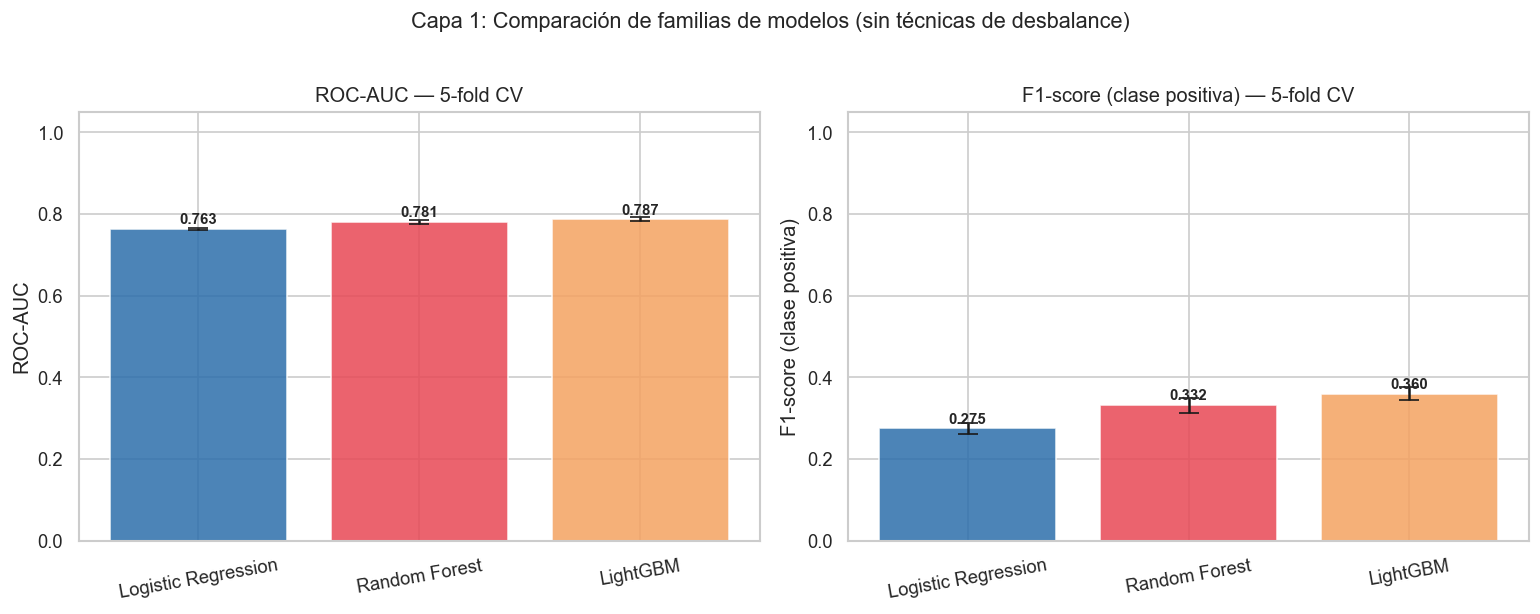

In [11]:
# ── Gráfica: comparación ROC-AUC y F1 — Capa 1 ───────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metrica, label in zip(
    axes,
    ["roc_auc", "f1"],
    ["ROC-AUC", "F1-score (clase positiva)"]
):
    medias = df_capa1[f"{metrica}_mean"]
    stds   = df_capa1[f"{metrica}_std"]
    modelos = df_capa1["modelo"]

    bars = ax.bar(modelos, medias, yerr=stds, capsize=6,
                  color=PALETTE[:len(modelos)], alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, medias):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{label} — 5-fold CV", fontsize=12)
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=10)

plt.suptitle("Capa 1: Comparación de familias de modelos (sin técnicas de desbalance)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../figures/fig_c1_comparacion_base.png", bbox_inches="tight")
plt.show()

---
## 4. Capa 2 — Experimento de leakage: con vs sin duration

In [12]:
# ── Preparación: dataset CON duration ────────────────────────────────────────
#
# Para este experimento específico INCLUIMOS duration en X para comparar.
# Esto simula el escenario de leakage que debemos evitar en producción.
#
# NOTA: esta versión solo se usa en esta sección comparativa.
# El modelado final siempre excluye duration.

X_full_con_dur = df.drop(columns=[TARGET])   # incluye duration
y_full_dur     = (df[TARGET] == "yes").astype(int)

X_train_dur, _, y_train_dur, _ = train_test_split(
    X_full_con_dur, y_full_dur,
    test_size=0.20, random_state=RANDOM_STATE, stratify=y_full_dur
)

# Preprocesador para el dataset con duration
num_cols_dur = X_train_dur.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols_dur = X_train_dur.select_dtypes(include="object").columns.tolist()

prep_dur = ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols_dur),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols_dur)
])

print("Dataset con duration listo para el experimento de leakage.")
print(f"  Columnas: {X_train_dur.shape[1]} (incluye 'duration')")

Dataset con duration listo para el experimento de leakage.
  Columnas: 16 (incluye 'duration')


In [13]:
# ── Ejecución del experimento de leakage ──────────────────────────────────────
#
# Comparamos los tres modelos en dos escenarios:
#   Escenario A (sin duration): modelo realista y desplegable
#   Escenario B (con duration): techo teórico — simula leakage

resultados_leakage = []

modelos_cfg = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest"      : RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "LightGBM"           : LGBMClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
}

print("=" * 65)
print("CAPA 2 — Experimento de leakage: sin vs con 'duration'")
print("=" * 65)

for nombre, modelo in modelos_cfg.items():
    print(f"\n  {nombre}")

    # Escenario A: sin duration (realista)
    pipe_sin = Pipeline([("prep", preprocessor), ("model", modelo)])
    cv_sin   = cross_validate(pipe_sin, X_train, y_train,
                              cv=CV, scoring=SCORING, n_jobs=-1)

    # Escenario B: con duration (leakage)
    pipe_con = Pipeline([("prep", prep_dur), ("model", modelo)])
    cv_con   = cross_validate(pipe_con, X_train_dur, y_train_dur,
                              cv=CV, scoring=SCORING, n_jobs=-1)

    for escenario, cv_res in [("Sin duration", cv_sin), ("Con duration", cv_con)]:
        fila = {
            "modelo"        : nombre,
            "escenario"     : escenario,
            "roc_auc_mean"  : cv_res["test_roc_auc"].mean(),
            "f1_mean"       : cv_res["test_f1"].mean(),
        }
        resultados_leakage.append(fila)
        print(f"    [{escenario}] ROC-AUC: {fila['roc_auc_mean']:.4f} | F1: {fila['f1_mean']:.4f}")

df_leakage = pd.DataFrame(resultados_leakage)

CAPA 2 — Experimento de leakage: sin vs con 'duration'

  Logistic Regression
    [Sin duration] ROC-AUC: 0.7628 | F1: 0.2749
    [Con duration] ROC-AUC: 0.9066 | F1: 0.4503

  Random Forest
    [Sin duration] ROC-AUC: 0.7807 | F1: 0.3318
    [Con duration] ROC-AUC: 0.9293 | F1: 0.4933

  LightGBM
    [Sin duration] ROC-AUC: 0.7871 | F1: 0.3596
    [Con duration] ROC-AUC: 0.9344 | F1: 0.5618


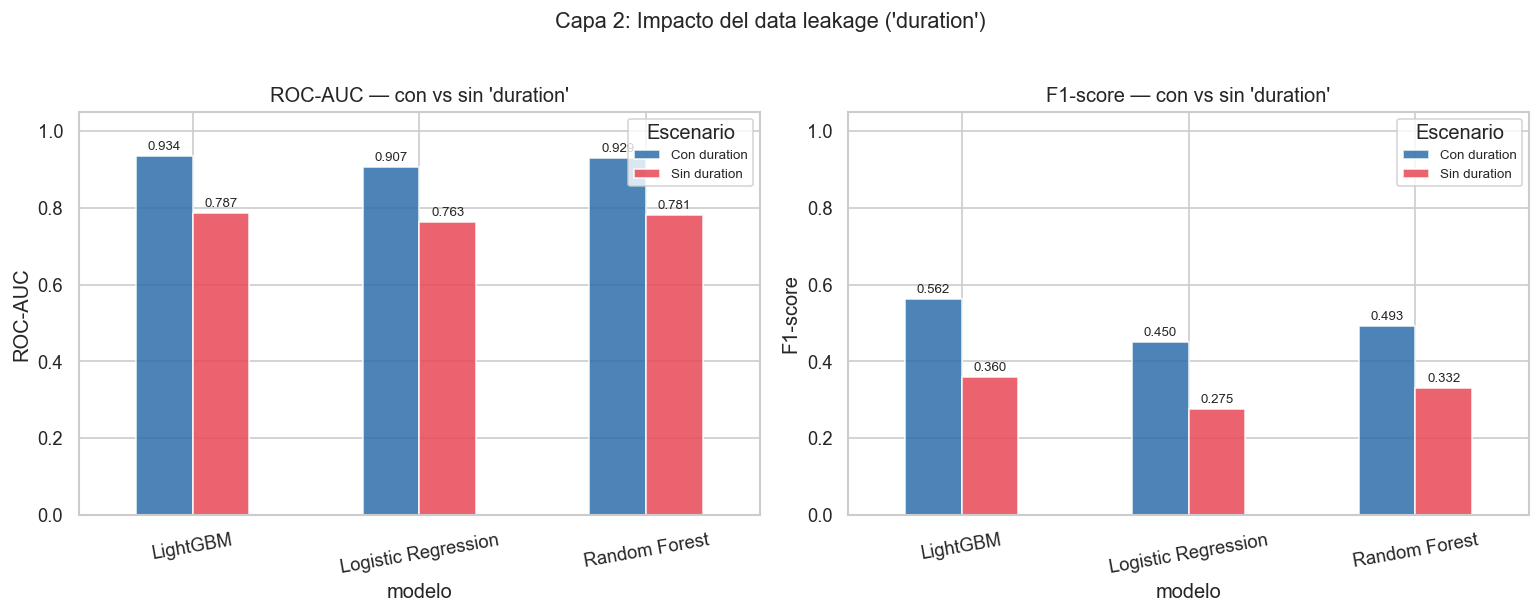

In [14]:
# ── Gráfica: impacto de duration en ROC-AUC ───────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metrica, label in zip(
    axes,
    ["roc_auc_mean", "f1_mean"],
    ["ROC-AUC", "F1-score"]
):
    pivot = df_leakage.pivot(index="modelo", columns="escenario", values=metrica)
    pivot.plot(kind="bar", ax=ax, color=[PALETTE[0], PALETTE[1]],
               alpha=0.85, edgecolor="white")
    ax.set_title(f"{label} — con vs sin 'duration'", fontsize=12)
    ax.set_ylabel(label)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=10)
    ax.legend(title="Escenario", fontsize=8)

    # Anotaciones de valor
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)

plt.suptitle("Capa 2: Impacto del data leakage ('duration')", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../figures/fig_c2_leakage.png", bbox_inches="tight")
plt.show()

In [15]:
# ── Cuantificación del inflado por leakage ────────────────────────────────────

print("── Diferencia en ROC-AUC atribuible a 'duration' ───────────")
for modelo in df_leakage["modelo"].unique():
    sub = df_leakage[df_leakage["modelo"] == modelo]
    sin = sub[sub["escenario"] == "Sin duration"]["roc_auc_mean"].values[0]
    con = sub[sub["escenario"] == "Con duration"]["roc_auc_mean"].values[0]
    delta = con - sin
    print(f"  {modelo:<22}: +{delta:.4f} ROC-AUC  ({sin:.4f} → {con:.4f})")

print()
print("Conclusión: incluir 'duration' infla artificialmente el ROC-AUC.")
print("Los modelos realistas (sin duration) son los válidos para despliegue.")

── Diferencia en ROC-AUC atribuible a 'duration' ───────────
  Logistic Regression   : +0.1438 ROC-AUC  (0.7628 → 0.9066)
  Random Forest         : +0.1486 ROC-AUC  (0.7807 → 0.9293)
  LightGBM              : +0.1473 ROC-AUC  (0.7871 → 0.9344)

Conclusión: incluir 'duration' infla artificialmente el ROC-AUC.
Los modelos realistas (sin duration) son los válidos para despliegue.


---
## 5. Capa 3 — Experimento de desbalance como variable de diseño

### Diseño del experimento: 3 modelos × 3 técnicas = 9 configuraciones

In [16]:
# ── Construcción de las 9 configuraciones del experimento ─────────────────────

configs = []

for modelo_nombre, ModeloClass, kwargs in [
    ("Logistic Regression",
     LogisticRegression,
     {"max_iter": 1000, "random_state": RANDOM_STATE}),

    ("Random Forest",
     RandomForestClassifier,
     {"n_estimators": 200, "random_state": RANDOM_STATE, "n_jobs": -1}),

    ("LightGBM",
     LGBMClassifier,
     {"n_estimators": 300, "random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1})
]:

    # ── Configuración A: Sin técnica de desbalance ────────────────────────────
    pipe_sin = Pipeline([
        ("prep",   preprocessor),
        ("model",  ModeloClass(**kwargs))
    ])
    configs.append((f"{modelo_nombre} | Sin técnica", pipe_sin))

    # ── Configuración B: class_weight='balanced' ──────────────────────────────
    # Ajusta los pesos inversamente proporcionales a la frecuencia de cada clase.
    # Disponible nativamente en LR y RF.
    # Para LightGBM usamos is_unbalance=True (equivalente).
    if modelo_nombre == "LightGBM":
        kwargs_cw = {**kwargs, "is_unbalance": True}
    else:
        kwargs_cw = {**kwargs, "class_weight": "balanced"}

    pipe_cw = Pipeline([
        ("prep",  preprocessor),
        ("model", ModeloClass(**kwargs_cw))
    ])
    configs.append((f"{modelo_nombre} | class_weight", pipe_cw))

    # ── Configuración C: SMOTE ────────────────────────────────────────────────
    # Usamos ImbPipeline (de imbalanced-learn) que integra pasos de
    # remuestreo correctamente dentro de cada pliegue de CV.
    # SMOTE solo se aplica a los datos de ENTRENAMIENTO de cada fold.
    pipe_smote = ImbPipeline([
        ("prep",   preprocessor),
        ("smote",  SMOTE(random_state=RANDOM_STATE)),
        ("model",  ModeloClass(**kwargs))
    ])
    configs.append((f"{modelo_nombre} | SMOTE", pipe_smote))

print(f"Configuraciones construidas: {len(configs)}")
for nombre, _ in configs:
    print(f"  → {nombre}")

Configuraciones construidas: 9
  → Logistic Regression | Sin técnica
  → Logistic Regression | class_weight
  → Logistic Regression | SMOTE
  → Random Forest | Sin técnica
  → Random Forest | class_weight
  → Random Forest | SMOTE
  → LightGBM | Sin técnica
  → LightGBM | class_weight
  → LightGBM | SMOTE


In [17]:
# ── Ejecución del experimento de desbalance (9 configuraciones) ───────────────

print("=" * 65)
print("CAPA 3 — Experimento de desbalance (3 modelos × 3 técnicas)")
print("Configuración: 5-fold CV estratificada | sin duration")
print("=" * 65)
print()

resultados_desbalance = []
for nombre, pipeline in configs:
    fila = evaluar_cv(nombre, pipeline, X_train, y_train)
    # Separar modelo y técnica para facilitar el análisis
    partes = nombre.split(" | ")
    fila["modelo"]   = partes[0]
    fila["tecnica"]  = partes[1]
    fila["config"]   = nombre
    resultados_desbalance.append(fila)

df_desbalance = pd.DataFrame(resultados_desbalance)

CAPA 3 — Experimento de desbalance (3 modelos × 3 técnicas)
Configuración: 5-fold CV estratificada | sin duration

  Logistic Regression | Sin técnica
    ROC-AUC : 0.7628 ± 0.0030
    F1-score: 0.2749 ± 0.0129
    Accuracy: 0.8922 ± 0.0007

  Logistic Regression | class_weight
    ROC-AUC : 0.7637 ± 0.0032
    F1-score: 0.3726 ± 0.0033
    Accuracy: 0.7550 ± 0.0055

  Logistic Regression | SMOTE
    ROC-AUC : 0.7582 ± 0.0034
    F1-score: 0.3634 ± 0.0040
    Accuracy: 0.7465 ± 0.0039

  Random Forest | Sin técnica
    ROC-AUC : 0.7807 ± 0.0056
    F1-score: 0.3318 ± 0.0183
    Accuracy: 0.8922 ± 0.0019

  Random Forest | class_weight
    ROC-AUC : 0.7777 ± 0.0060
    F1-score: 0.3087 ± 0.0184
    Accuracy: 0.8924 ± 0.0016

  Random Forest | SMOTE
    ROC-AUC : 0.7711 ± 0.0054
    F1-score: 0.3815 ± 0.0213
    Accuracy: 0.8829 ± 0.0022

  LightGBM | Sin técnica
    ROC-AUC : 0.7871 ± 0.0051
    F1-score: 0.3596 ± 0.0154
    Accuracy: 0.8921 ± 0.0021

  LightGBM | class_weight
    ROC-A

In [18]:
# ── Tabla completa del experimento de desbalance ──────────────────────────────

tabla_desbalance = (
    df_desbalance[["modelo", "tecnica", "roc_auc_mean", "roc_auc_std",
                   "f1_mean", "f1_std", "accuracy_mean"]]
    .rename(columns={
        "modelo"        : "Modelo",
        "tecnica"       : "Técnica",
        "roc_auc_mean"  : "ROC-AUC",
        "roc_auc_std"   : "AUC±std",
        "f1_mean"       : "F1",
        "f1_std"        : "F1±std",
        "accuracy_mean" : "Accuracy"
    })
    .sort_values(["ROC-AUC", "F1"], ascending=False)
    .reset_index(drop=True)
)

print("── Tabla completa: 9 configuraciones ────────────────────────")
print(tabla_desbalance.to_string(index=False, float_format="{:.4f}".format))

── Tabla completa: 9 configuraciones ────────────────────────
             Modelo      Técnica  ROC-AUC  AUC±std     F1  F1±std  Accuracy
           LightGBM  Sin técnica   0.7871   0.0051 0.3596  0.0154    0.8921
           LightGBM        SMOTE   0.7835   0.0040 0.3822  0.0194    0.8917
           LightGBM class_weight   0.7831   0.0048 0.4535  0.0032    0.8365
      Random Forest  Sin técnica   0.7807   0.0056 0.3318  0.0183    0.8922
      Random Forest class_weight   0.7777   0.0060 0.3087  0.0184    0.8924
      Random Forest        SMOTE   0.7711   0.0054 0.3815  0.0213    0.8829
Logistic Regression class_weight   0.7637   0.0032 0.3726  0.0033    0.7550
Logistic Regression  Sin técnica   0.7628   0.0030 0.2749  0.0129    0.8922
Logistic Regression        SMOTE   0.7582   0.0034 0.3634  0.0040    0.7465


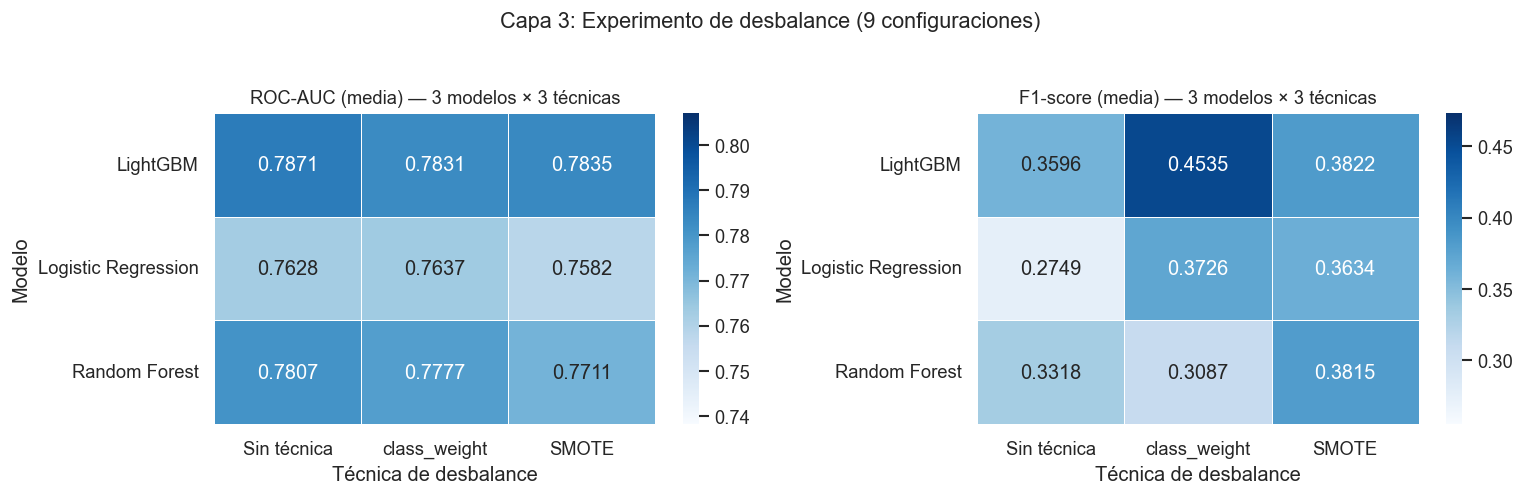

In [19]:
# ── Heatmap del experimento de desbalance ─────────────────────────────────────
#
# Visualizamos la tabla 3×3 como heatmap: filas=modelos, columnas=técnicas.
# Generamos uno para ROC-AUC y otro para F1-score.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metrica, label in zip(
    axes,
    ["roc_auc_mean", "f1_mean"],
    ["ROC-AUC (media)", "F1-score (media)"]
):
    pivot = df_desbalance.pivot(index="modelo", columns="tecnica", values=metrica)
    # Ordenar columnas
    pivot = pivot[[c for c in ["Sin técnica", "class_weight", "SMOTE"] if c in pivot.columns]]

    sns.heatmap(
        pivot, annot=True, fmt=".4f", cmap="Blues",
        vmin=pivot.values.min() - 0.02,
        vmax=pivot.values.max() + 0.02,
        linewidths=0.5, ax=ax
    )
    ax.set_title(f"{label} — 3 modelos × 3 técnicas", fontsize=11)
    ax.set_xlabel("Técnica de desbalance")
    ax.set_ylabel("Modelo")

plt.suptitle("Capa 3: Experimento de desbalance (9 configuraciones)",
             fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig("../figures/fig_c3_desbalance_heatmap.png", bbox_inches="tight")
plt.show()

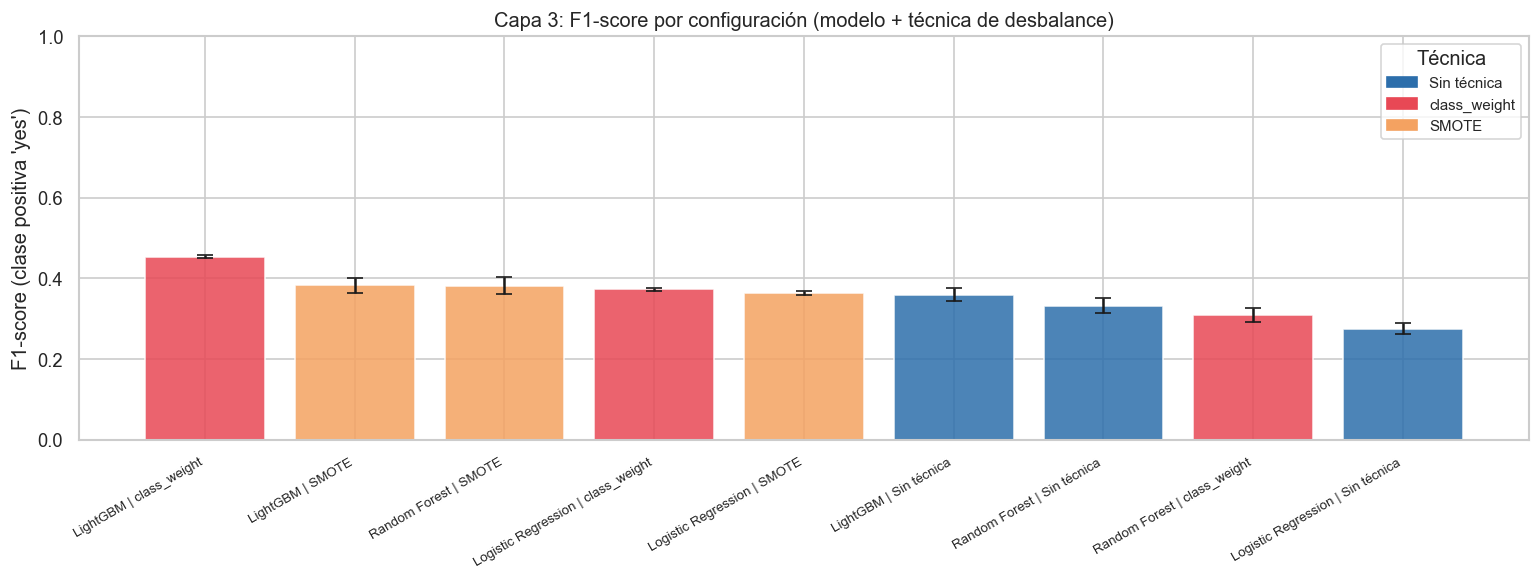

In [20]:
# ── Gráfica de barras: F1-score por configuración ─────────────────────────────
#
# El F1 en la clase positiva es la métrica más sensible al desbalance.
# Esta gráfica muestra qué combinación modelo+técnica lo maximiza.

orden = df_desbalance.sort_values("f1_mean", ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))

colores_tecnica = {
    "Sin técnica" : PALETTE[0],
    "class_weight": PALETTE[1],
    "SMOTE"       : PALETTE[2]
}

bars = ax.bar(
    range(len(orden)),
    orden["f1_mean"],
    yerr=orden["f1_std"],
    capsize=5,
    color=[colores_tecnica.get(t, "#999") for t in orden["tecnica"]],
    alpha=0.85,
    edgecolor="white"
)
ax.set_xticks(range(len(orden)))
ax.set_xticklabels(orden["config"], rotation=30, ha="right", fontsize=8)
ax.set_ylabel("F1-score (clase positiva 'yes')")
ax.set_title("Capa 3: F1-score por configuración (modelo + técnica de desbalance)", fontsize=12)
ax.set_ylim(0, 1.0)

# Leyenda manual de colores
from matplotlib.patches import Patch
leyenda = [Patch(color=c, label=t) for t, c in colores_tecnica.items()]
ax.legend(handles=leyenda, title="Técnica", fontsize=9)

plt.tight_layout()
plt.savefig("../figures/fig_c3_f1_configs.png", bbox_inches="tight")
plt.show()

---
## 6. Análisis de umbral de decisión

In [21]:
# ── Identificamos la mejor configuración de la Capa 3 ────────────────────────
#
# Seleccionamos la configuración con mayor F1 en CV para el análisis de umbral.
# Este modelo se entrena sobre TODO X_train para generar probabilidades
# en una validación hold-out interna.

mejor_config_nombre = df_desbalance.sort_values("f1_mean", ascending=False).iloc[0]["config"]
print(f"Mejor configuración (por F1 en CV): {mejor_config_nombre}")

# Recuperamos el pipeline correspondiente
mejor_pipeline = dict(configs)[mejor_config_nombre]

# División interna para análisis de umbral (80/20 dentro de train)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.20, random_state=RANDOM_STATE, stratify=y_train
)

mejor_pipeline.fit(X_tr, y_tr)
y_proba_val = mejor_pipeline.predict_proba(X_val)[:, 1]

print(f"Modelo entrenado sobre {len(X_tr):,} muestras.")
print(f"Probabilidades calculadas sobre {len(X_val):,} muestras de validación interna.")

Mejor configuración (por F1 en CV): LightGBM | class_weight
Modelo entrenado sobre 28,934 muestras.
Probabilidades calculadas sobre 7,234 muestras de validación interna.


Umbral óptimo (máx F1): 0.6416
F1-score en umbral óptimo: 0.4804


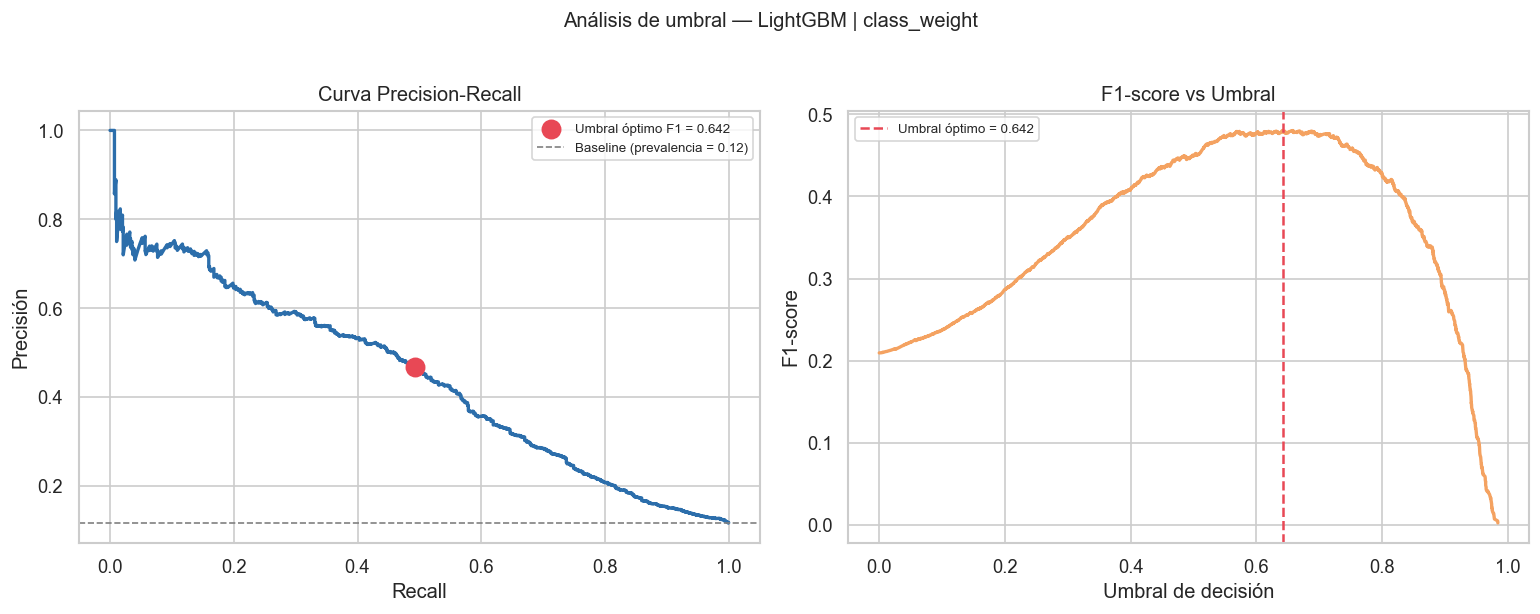

In [22]:
# ── Curva Precision-Recall y umbral óptimo F1 ─────────────────────────────────

precision, recall, thresholds = precision_recall_curve(y_val, y_proba_val)

# F1 para cada umbral (evitar división por cero)
f1_scores = np.where(
    (precision[:-1] + recall[:-1]) > 0,
    2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1]),
    0
)

umbral_optimo = thresholds[np.argmax(f1_scores)]
f1_optimo     = f1_scores.max()

print(f"Umbral óptimo (máx F1): {umbral_optimo:.4f}")
print(f"F1-score en umbral óptimo: {f1_optimo:.4f}")

# ── Gráfica ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: curva Precision-Recall
axes[0].plot(recall, precision, color=PALETTE[0], linewidth=2)
idx = np.argmax(f1_scores)
axes[0].scatter(recall[idx], precision[idx], color=PALETTE[1], s=120, zorder=5,
                label=f"Umbral óptimo F1 = {umbral_optimo:.3f}")
axes[0].axhline(y_train.mean(), color="gray", linestyle="--", linewidth=1,
                label=f"Baseline (prevalencia = {y_train.mean():.2f})")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precisión")
axes[0].set_title("Curva Precision-Recall", fontsize=12)
axes[0].legend(fontsize=8)

# Panel derecho: F1 vs umbral
axes[1].plot(thresholds, f1_scores, color=PALETTE[2], linewidth=2)
axes[1].axvline(umbral_optimo, color=PALETTE[1], linestyle="--", linewidth=1.5,
                label=f"Umbral óptimo = {umbral_optimo:.3f}")
axes[1].set_xlabel("Umbral de decisión")
axes[1].set_ylabel("F1-score")
axes[1].set_title("F1-score vs Umbral", fontsize=12)
axes[1].legend(fontsize=8)

plt.suptitle(f"Análisis de umbral — {mejor_config_nombre}", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../figures/fig_c4_umbral.png", bbox_inches="tight")
plt.show()

In [23]:
# ── Comparación: umbral por defecto (0.5) vs umbral óptimo ────────────────────

for umbral, etiqueta in [(0.5, "Umbral default (0.5)"), (umbral_optimo, f"Umbral óptimo ({umbral_optimo:.3f})")]:
    y_pred_u = (y_proba_val >= umbral).astype(int)
    print(f"── {etiqueta} ───────────────────────────")
    print(f"  F1-score : {f1_score(y_val, y_pred_u):.4f}")
    print(f"  Recall   : {recall[np.argmin(np.abs(thresholds - umbral))]:.4f}" if umbral != 0.5
          else f"  Recall   : {recall[np.argmin(np.abs(thresholds - 0.5))]:.4f}")
    print(f"  Accuracy : {accuracy_score(y_val, y_pred_u):.4f}")
    print()

── Umbral default (0.5) ───────────────────────────
  F1-score : 0.4496
  Recall   : 0.5875
  Accuracy : 0.8318

── Umbral óptimo (0.642) ───────────────────────────
  F1-score : 0.4804
  Recall   : 0.4929
  Accuracy : 0.8753



---
## 7. Análisis de errores — Evaluación final sobre test

In [24]:
# ── Entrenamiento final sobre X_train completo ────────────────────────────────

print(f"Modelo final: {mejor_config_nombre}")
print(f"Umbral de decisión: {umbral_optimo:.4f}")
print()

# Reentrenamos sobre TODO X_train (no solo la partición interna)
mejor_pipeline.fit(X_train, y_train)

# Predicciones sobre test
y_proba_test = mejor_pipeline.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba_test >= 0.50).astype(int)
y_pred_optimo  = (y_proba_test >= umbral_optimo).astype(int)

print("── Métricas sobre conjunto de TEST ─────────────────────────")
print()
for preds, etiqueta in [(y_pred_default, "Umbral 0.5  "), (y_pred_optimo, f"Umbral {umbral_optimo:.3f}")]:
    print(f"  [{etiqueta}]")
    print(f"    ROC-AUC  : {roc_auc_score(y_test, y_proba_test):.4f}")
    print(f"    F1-score : {f1_score(y_test, preds):.4f}")
    print(f"    Accuracy : {accuracy_score(y_test, preds):.4f}")
    print()

Modelo final: LightGBM | class_weight
Umbral de decisión: 0.6416

── Métricas sobre conjunto de TEST ─────────────────────────

  [Umbral 0.5  ]
    ROC-AUC  : 0.7871
    F1-score : 0.4579
    Accuracy : 0.8327

  [Umbral 0.642]
    ROC-AUC  : 0.7871
    F1-score : 0.4831
    Accuracy : 0.8786



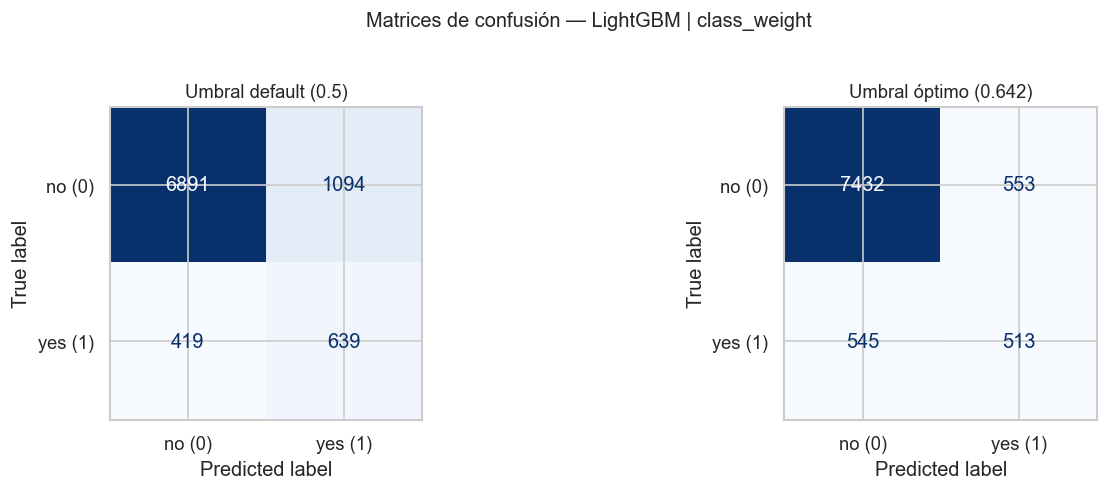

In [25]:
# ── Matrices de confusión: umbral default vs óptimo ───────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, titulo in [
    (axes[0], y_pred_default, "Umbral default (0.5)"),
    (axes[1], y_pred_optimo,  f"Umbral óptimo ({umbral_optimo:.3f})")
]:
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels=["no (0)", "yes (1)"],
        colorbar=False, ax=ax, cmap="Blues"
    )
    ax.set_title(titulo, fontsize=11)

plt.suptitle(f"Matrices de confusión — {mejor_config_nombre}", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../figures/fig_c5_confusion_final.png", bbox_inches="tight")
plt.show()

In [26]:
# ── Reporte de clasificación completo ─────────────────────────────────────────

print("── Reporte de clasificación (umbral óptimo) ────────────────")
print(classification_report(y_test, y_pred_optimo, target_names=["no", "yes"]))

── Reporte de clasificación (umbral óptimo) ────────────────
              precision    recall  f1-score   support

          no       0.93      0.93      0.93      7985
         yes       0.48      0.48      0.48      1058

    accuracy                           0.88      9043
   macro avg       0.71      0.71      0.71      9043
weighted avg       0.88      0.88      0.88      9043



In [27]:
# ── Análisis de perfil de error ───────────────────────────────────────────────
#
# ¿Qué características tienen los clientes que el modelo clasifica mal?
# Comparamos los Falsos Negativos (clientes que SÍ aceptarían pero el
# modelo predice NO) vs los Verdaderos Positivos (correctamente detectados).
#
# Esto permite entender los límites del modelo y generar recomendaciones.

X_test_reset  = X_test.reset_index(drop=True)
y_test_reset  = y_test.reset_index(drop=True)
y_pred_reset  = pd.Series(y_pred_optimo, name="pred")

# Casos positivos reales
mask_pos  = y_test_reset == 1
mask_fn   = (y_test_reset == 1) & (y_pred_reset == 0)  # Falsos Negativos
mask_tp   = (y_test_reset == 1) & (y_pred_reset == 1)  # Verdaderos Positivos

df_fn = X_test_reset[mask_fn]
df_tp = X_test_reset[mask_tp]

print(f"Falsos Negativos (FN): {mask_fn.sum():,} — clientes que aceptarían pero el modelo dice NO")
print(f"Verdaderos Positivos (TP): {mask_tp.sum():,} — correctamente detectados")
print()

# Comparación en variables numéricas clave
num_comparar = ["age", "balance", "campaign", "pdays", "previous"]
comparacion = pd.DataFrame({
    "FN (media)"  : df_fn[num_comparar].mean(),
    "TP (media)"  : df_tp[num_comparar].mean(),
    "Diferencia"  : df_fn[num_comparar].mean() - df_tp[num_comparar].mean()
})

print("── Perfil de error: FN vs TP (variables numéricas) ─────────")
print(comparacion.round(2).to_string())

Falsos Negativos (FN): 545 — clientes que aceptarían pero el modelo dice NO
Verdaderos Positivos (TP): 513 — correctamente detectados

── Perfil de error: FN vs TP (variables numéricas) ─────────
          FN (media)  TP (media)  Diferencia
age            40.80       43.06       -2.26
balance      1515.66     1903.78     -388.13
campaign        2.44        1.75        0.68
pdays          44.63      101.15      -56.52
previous        0.60        1.78       -1.18


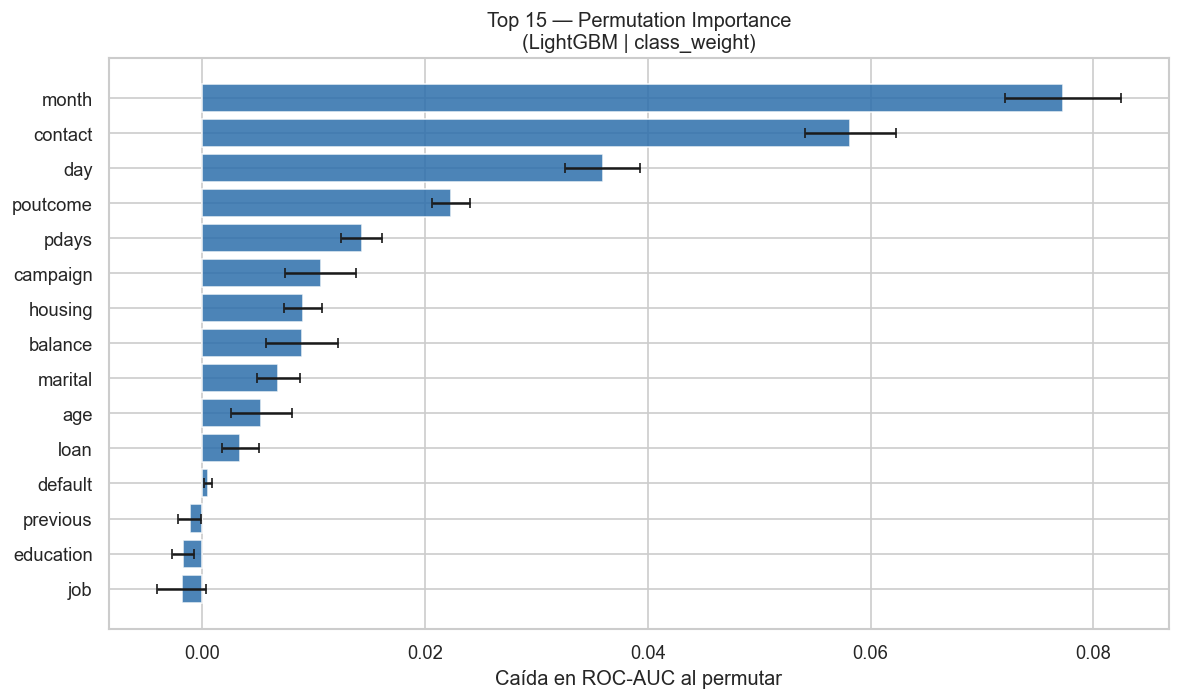


Top 10 variables más importantes:
variable  importancia    std
   month       0.0773 0.0052
 contact       0.0582 0.0041
     day       0.0359 0.0034
poutcome       0.0223 0.0017
   pdays       0.0143 0.0018
campaign       0.0107 0.0032
 housing       0.0091 0.0017
 balance       0.0090 0.0032
 marital       0.0068 0.0019
     age       0.0053 0.0027


In [28]:
# ── Importancia de variables (permutation importance) ─────────────────────────
#
# Permutation importance es más honesta que feature_importances_ de árbol:
# mide cuánto cae el ROC-AUC cuando aleatorizamos una variable.
# Si la caída es grande, la variable es importante; si es pequeña, no lo es.
#
# La calculamos sobre la validación interna (X_val) para no contaminar test.

from sklearn.inspection import permutation_importance

# Reentrenamos sobre X_tr (partición interna) para calcular sobre X_val
mejor_pipeline.fit(X_tr, y_tr)

perm_result = permutation_importance(
    mejor_pipeline, X_val, y_val,
    n_repeats    = 15,
    random_state = RANDOM_STATE,
    scoring      = "roc_auc",
    n_jobs       = -1
)

# Construir DataFrame de importancias
importancias = pd.DataFrame({
    "variable"   : X_train.columns,
    "importancia": perm_result.importances_mean,
    "std"        : perm_result.importances_std
}).sort_values("importancia", ascending=False)

top15 = importancias.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top15["variable"][::-1], top15["importancia"][::-1],
        xerr=top15["std"][::-1], color=PALETTE[0], alpha=0.85,
        edgecolor="white", capsize=3)
ax.set_xlabel("Caída en ROC-AUC al permutar")
ax.set_title(f"Top 15 — Permutation Importance\n({mejor_config_nombre})", fontsize=12)
plt.tight_layout()
plt.savefig("../figures/fig_c6_permutation_importance.png", bbox_inches="tight")
plt.show()

print("\nTop 10 variables más importantes:")
print(importancias.head(10)[["variable","importancia","std"]].to_string(index=False, float_format="{:.4f}".format))

---
## 8. Decisión provisional y tabla resumen

### Resumen de todos los experimentos

In [29]:
# ── Tabla resumen global ──────────────────────────────────────────────────────

print("=" * 70)
print("RESUMEN GLOBAL — todos los experimentos")
print("=" * 70)

print("\n── Capa 1: Tres familias base (sin técnica de desbalance) ───")
print(tabla_capa1.to_string(index=False, float_format="{:.4f}".format))

print("\n── Capa 3: Mejor configuración por F1 (en CV) ──────────────")
top3 = (
    df_desbalance
    .sort_values("f1_mean", ascending=False)
    .head(3)[["modelo", "tecnica", "roc_auc_mean", "f1_mean"]]
    .rename(columns={"modelo":"Modelo", "tecnica":"Técnica",
                     "roc_auc_mean":"ROC-AUC", "f1_mean":"F1"})
)
print(top3.to_string(index=False, float_format="{:.4f}".format))

print(f"\n── Modelo final sobre TEST ─────────────────────────────────")
print(f"  Configuración : {mejor_config_nombre}")
print(f"  Umbral        : {umbral_optimo:.4f}")
print(f"  ROC-AUC (test): {roc_auc_score(y_test, y_proba_test):.4f}")
print(f"  F1-score(test): {f1_score(y_test, y_pred_optimo):.4f}")
print(f"  Accuracy(test): {accuracy_score(y_test, y_pred_optimo):.4f}")

RESUMEN GLOBAL — todos los experimentos

── Capa 1: Tres familias base (sin técnica de desbalance) ───
             Modelo  ROC-AUC (media)  ROC-AUC (±std)  F1 (media)  F1 (±std)  Accuracy (media)
           LightGBM           0.7871          0.0051      0.3596     0.0154            0.8921
      Random Forest           0.7807          0.0056      0.3318     0.0183            0.8922
Logistic Regression           0.7628          0.0030      0.2749     0.0129            0.8922

── Capa 3: Mejor configuración por F1 (en CV) ──────────────
       Modelo      Técnica  ROC-AUC     F1
     LightGBM class_weight   0.7831 0.4535
     LightGBM        SMOTE   0.7835 0.3822
Random Forest        SMOTE   0.7711 0.3815

── Modelo final sobre TEST ─────────────────────────────────
  Configuración : LightGBM | class_weight
  Umbral        : 0.6416
  ROC-AUC (test): 0.7871
  F1-score(test): 0.4831
  Accuracy(test): 0.8786
